# 02. Feature Engineering

**Goal:** Transform the raw Bloomberg data into a machine-learning-ready dataset.

**Methodology:**
1.  **Feature Selection:** Filter redundant factors using correlation analysis.
2.  **Target Engineering:** Optimize outlier clipping for the Target (`FwdRet`) using a "Bake-off" against the GFC period.
3.  **Categorical Encoding:** Select the optimal GICS classification level using a Bayesian Ridge cross-validation "Bake-off".

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath('..'))

from src.utils.config_loader import load_config
from src.utils.logger import setup_logger
from src.loaders.data_loader import DataLoader

logger = setup_logger("02_feature_engineering")
config = load_config()

# Load Data
loader = DataLoader(config)
df = loader.load_raw_data()

2026-03-06 14:01:37,799 - INFO - Loading data from /Users/aengusmartindonaire/Downloads/Projects/systematic-equity-alpha/data/raw/20251109_Blg_Rsk_Factors.par...
2026-03-06 14:01:38,285 - INFO - Data loaded successfully. Shape: (170902, 33)


In [2]:
df.columns

Index(['Short Name', 'Ticker.1', 'Sz', 'Prof', 'Vol', 'Trd Act', 'Lev', 'Mom',
       'Val', 'Gr', 'Dvd Yld', 'Earn Var', 'P/S', 'BEst P/S BF12M', 'P/B',
       'BEst P/B BF12M', 'P/E', 'BEst P/E BF12M', 'ROE LF', 'GICS_Sector',
       'GICS_Industry', 'GICS_SubInd', 'GICS_Sector_Name',
       'GICS_Industry_Name', 'GICS_SubInd_Name',
       'ESG Disclosure Score (Latest Available) (BLOOMBERG L.P.)', 'Beta:Y-1',
       'Total Return:Y-1', 'Number of Employees:Y', 'Number of Employees:Y-5',
       'Market Cap', 'Total Return:M-3', 'FwdRet'],
      dtype='object')

### **Understand Data Structure:** 

Before any analysis, we review the column names and categorize them. 

In [3]:
# Column groups from the project spec
rsk_cols = ['Sz', 'Prof', 'Vol', 'Trd Act', 'Lev', 'Mom', 'Val', 'Gr', 'Dvd Yld', 'Earn Var']

extranames = ['P/S', 'BEst P/S BF12M', 'P/B', 'BEst P/B BF12M',
              'P/E', 'BEst P/E BF12M', 'ROE LF', 'Beta:Y-1',
               'Total Return:Y-1', 'Number of Employees:Y', 'Market Cap']

# Identify GICS classification columns
gics_cols = [c for c in df.columns if 'GICS' in c]

print("Total columns:", len(df.columns))
print("\nRisk factor columns (rsk_cols):")
print(rsk_cols)

print("\nExtra feature columns (extranames):")
print(extranames)

print("\nGICS-related columns:")
print(gics_cols)

Total columns: 33

Risk factor columns (rsk_cols):
['Sz', 'Prof', 'Vol', 'Trd Act', 'Lev', 'Mom', 'Val', 'Gr', 'Dvd Yld', 'Earn Var']

Extra feature columns (extranames):
['P/S', 'BEst P/S BF12M', 'P/B', 'BEst P/B BF12M', 'P/E', 'BEst P/E BF12M', 'ROE LF', 'Beta:Y-1', 'Total Return:Y-1', 'Number of Employees:Y', 'Market Cap']

GICS-related columns:
['GICS_Sector', 'GICS_Industry', 'GICS_SubInd', 'GICS_Sector_Name', 'GICS_Industry_Name', 'GICS_SubInd_Name']


In [4]:
# Only keep the features that actually exist in the DataFrame
num_cols = [c for c in (rsk_cols + extranames) if c in df.columns]

print("Number of numeric features in rsk_cols + extranames that are present:", len(num_cols))
print("First few numeric features:", num_cols[:5])

# Descriptive statistics for these numeric features
desc_stats = df[num_cols].describe().T
display(desc_stats)

Number of numeric features in rsk_cols + extranames that are present: 21
First few numeric features: ['Sz', 'Prof', 'Vol', 'Trd Act', 'Lev']


,count,mean,std,min,25%,50%,75%,max
Sz,170902.0,-1.812594e+00,9.927287e-01,-2.999999e+00,-2.606263e+00,-2.065954e+00,-1.261186e+00,2.263810e+00
Prof,170902.0,-4.996548e-01,9.190336e-01,-3.000674e+00,-9.086650e-01,-5.209301e-01,-4.725492e-02,3.000625e+00
Vol,170902.0,6.092810e-02,1.024525e+00,-3.000129e+00,-6.117792e-01,-8.845874e-02,5.758223e-01,3.000134e+00
Trd Act,170902.0,2.139891e-01,9.784090e-01,-9.999868e-01,-4.769185e-01,-8.096298e-02,5.963508e-01,3.000421e+00
Lev,170902.0,1.606740e-01,9.821112e-01,-1.513794e+00,-6.118940e-01,7.627911e-02,8.112825e-01,3.000000e+00
Mom,170902.0,-7.369054e-02,1.018846e+00,-3.000255e+00,-6.590508e-01,-9.878355e-02,4.748328e-01,3.000256e+00
Val,170902.0,2.235249e-01,9.789385e-01,-3.000163e+00,-3.730486e-01,1.516582e-01,7.814609e-01,3.000165e+00
Gr,170902.0,-6.007269e-02,9.579689e-01,-3.000120e+00,-6.621283e-01,-2.135612e-01,4.384211e-01,3.000191e+00
Dvd Yld,170902.0,-1.578354e-01,9.322656e-01,-1.108031e+00,-8.678002e-01,-4.795539e-01,2.875466e-01,3.000507e+00
Earn Var,170902.0,1.102690e-01,9.264639e-01,-1.351087e+00,-5.774061e-01,-1.186511e-01,5.741870e-01,3.000237e+00


In [5]:
# Standard deviations for numeric features
stds = desc_stats['std']

# Drop any features with NaN std (e.g., constant columns)
stds = stds.dropna()

max_std_feat = stds.idxmax()
min_std_feat = stds.idxmin()

scale_ratio = stds.max() / stds.min()

print(f"Largest std feature: {max_std_feat} = {stds.max():.4e}")
print(f"Smallest std feature: {min_std_feat} = {stds.min():.4e}")
print(f"Ratio (max std / min std): {scale_ratio:.4e}")

Largest std feature: Market Cap = 6.8919e+10
Smallest std feature: Prof = 9.1903e-01
Ratio (max std / min std): 7.4990e+10


>`Prof` has a standard deviation of ~9.1903e-01, while `Market Cap` is ~6.8919e+10, so the ratio is on the order of 7.4990e+10.

/Users/aengusmartindonaire/.conda/envs/hedging_clean/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


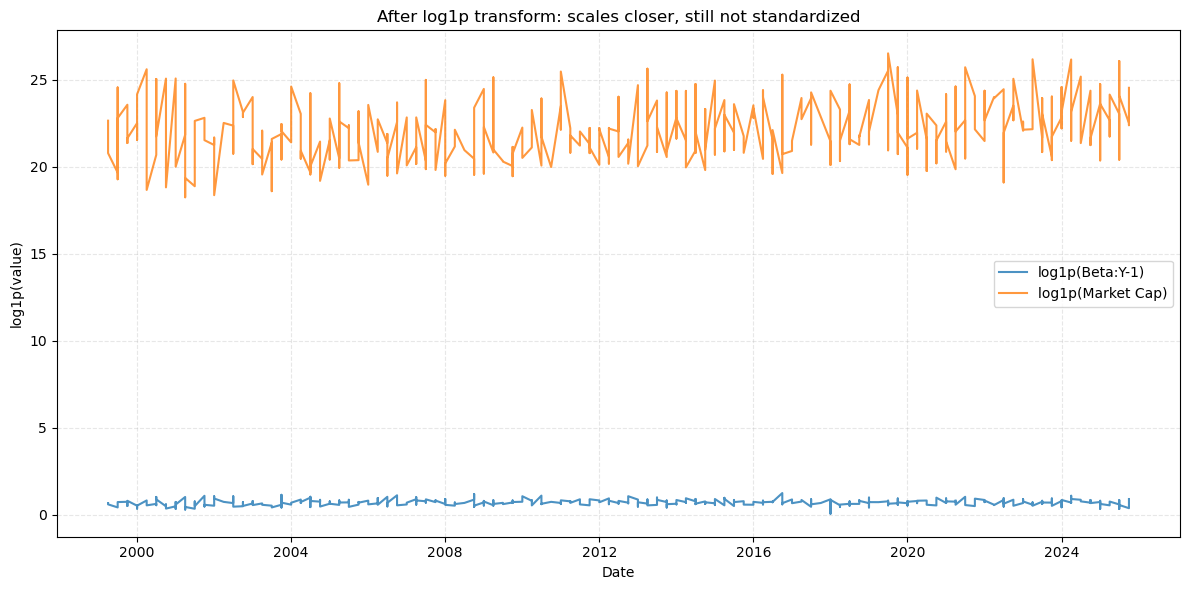

In [6]:
from src.utils.visualizations import plot_log_comparison

# This handles the MultiIndex automatically
plot_log_comparison(df, 'Beta:Y-1', 'Market Cap', n_samples=500)

This graph show that even with a simple transformation they’re still not on equal footing.

> **Therefore, the data still need proper standardization via StandardScaler in the pipeline IF we include both in our feature matrix (spoiler alert: we didn't include one of them!).**

In [8]:
redundant_cols = ['GICS_Sector', 'GICS_Industry', 'GICS_SubInd', 'Ticker.1']

print("Checking for redundant coding columns:")
for col in redundant_cols:
    if col in df.columns:
        print(f"  {col}: present (candidate to drop later)")
    else:
        print(f"  {col}: NOT FOUND")

print("\nGICS name columns (human-readable):")
for col in gics_cols:
    if 'Name' in col:
        print(" ", col)

Checking for redundant coding columns:
  GICS_Sector: present (candidate to drop later)
  GICS_Industry: present (candidate to drop later)
  GICS_SubInd: present (candidate to drop later)
  Ticker.1: present (candidate to drop later)

GICS name columns (human-readable):
  GICS_Sector_Name
  GICS_Industry_Name
  GICS_SubInd_Name


### **Feature Set Analysis: Risk Factors, Extra Features, & Multicollinearity**

Before modeling, you must understand your predictors. This involves analyzing the 10 proprietary `rsk_cols` and then deciding which of the 11 `extranames` are **novel** (add predictive value) and which are **redundant** (just add noise).


#### **Part A: Core Risk Factor Analysis**

First, analyze the 10 core factors provided by Bloomberg.


In [9]:
# Core risk factor list
rsk_cols = [
    'Sz',       # Size
    'Prof',     # Profitability
    'Vol',      # Volatility
    'Trd Act',  # Trading Activity
    'Lev',      # Leverage
    'Mom',      # Momentum
    'Val',      # Value
    'Gr',       # Growth
    'Dvd Yld',  # Dividend Yield
    'Earn Var'  # Earnings Variability
]

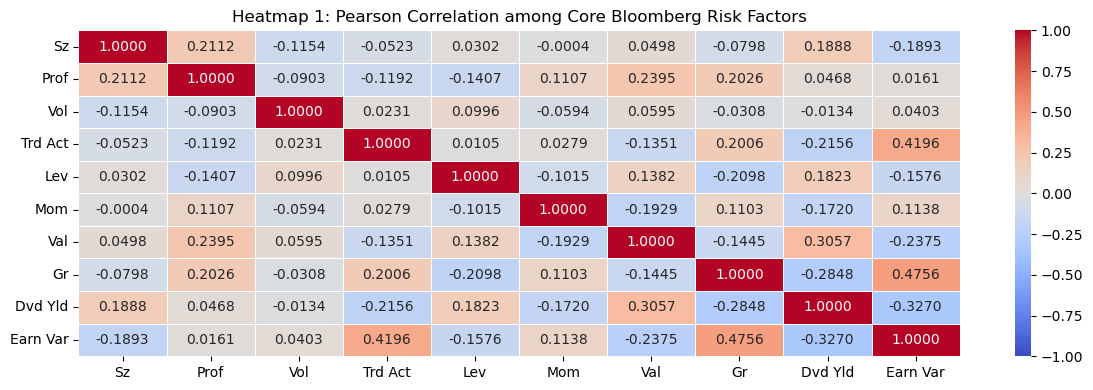

In [10]:
from src.utils.visualizations import plot_correlation_heatmap

# Plot Heatmap 1: Core Bloomberg Risk Factors
plot_correlation_heatmap(df, rsk_cols, 
    title="Heatmap 1: Pearson Correlation among Core Bloomberg Risk Factors")

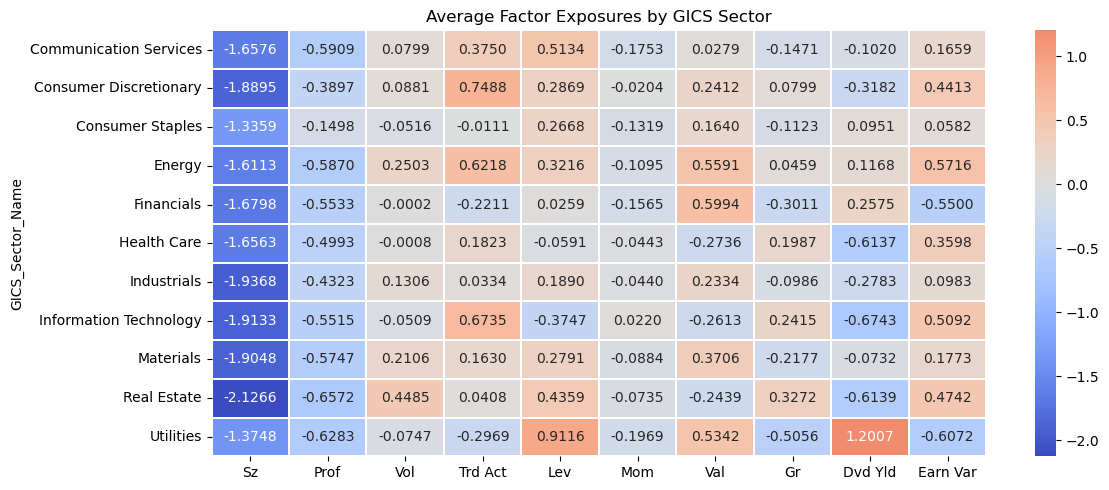

In [11]:
from src.utils.visualizations import plot_grouped_heatmap

# Plot Average Factor Exposures by GICS Sector
plot_grouped_heatmap(
    df, 
    group_col='GICS_Sector_Name', 
    value_cols=rsk_cols, 
    title="Average Factor Exposures by GICS Sector"
)

#### **Part B: "Extra" Feature Novelty Check**

Now, we use the core factors as a baseline to determine which of the 11 extranames are worth adding to your model.

In [12]:
# Extra feature list
extranames = [
    'P/S', 'BEst P/S BF12M',
    'P/B', 'BEst P/B BF12M',
    'P/E', 'BEst P/E BF12M',
    'ROE LF', 'Beta:Y-1',
    'Total Return:Y-1',
    'Number of Employees:Y',
    'Market Cap'
]

In [13]:
# Full correlation matrix (core + extra)
all_cols = rsk_cols + extranames
full_corr = df[all_cols].corr(method="pearson")

full_corr

,Sz,Prof,Vol,Trd Act,Lev,Mom,Val,Gr,Dvd Yld,Earn Var,...,BEst P/S BF12M,P/B,BEst P/B BF12M,P/E,BEst P/E BF12M,ROE LF,Beta:Y-1,Total Return:Y-1,Number of Employees:Y,Market Cap
Sz,1.000000,0.211225,-0.115431,-0.052323,0.030229,-0.000377,0.049822,-0.079804,0.188823,-0.189291,...,-0.087455,0.053877,-0.173996,-0.180834,-0.201304,0.200358,-0.003215,-0.005391,0.408619,0.386767
Prof,0.211225,1.000000,-0.090331,-0.119210,-0.140718,0.110741,0.239478,0.202601,0.046844,0.016062,...,0.032612,0.242930,0.056771,-0.429937,-0.293681,0.781047,-0.004013,-0.005818,0.060425,0.117609
Vol,-0.115431,-0.090331,1.000000,0.023149,0.099608,-0.059370,0.059548,-0.030764,-0.013392,0.040345,...,-0.031976,-0.017751,0.000721,0.130315,0.108003,-0.089335,0.038581,-0.014582,-0.001444,-0.011564
Trd Act,-0.052323,-0.119210,0.023149,1.000000,0.010544,0.027943,-0.135075,0.200625,-0.215572,0.419573,...,-0.118685,0.125115,-0.097613,0.188388,0.128087,-0.093272,0.033393,0.009305,-0.054175,-0.047670
Lev,0.030229,-0.140718,0.099608,0.010544,1.000000,-0.101506,0.138230,-0.209841,0.182258,-0.157604,...,-0.117110,0.144063,0.059831,0.021430,-0.014857,-0.091275,0.003824,-0.012378,0.027260,-0.037600
Mom,-0.000377,0.110741,-0.059370,0.027943,-0.101506,1.000000,-0.192905,0.110339,-0.172026,0.113778,...,0.081078,0.200126,0.085307,0.081025,0.043538,0.112362,0.008702,0.076431,-0.024485,0.018272
Val,0.049822,0.239478,0.059548,-0.135075,0.138230,-0.192905,1.000000,-0.144470,0.305741,-0.237456,...,-0.163800,-0.363073,-0.005630,-0.540832,-0.433125,0.236681,-0.017200,-0.013788,0.024615,-0.040600
Gr,-0.079804,0.202601,-0.030764,0.200625,-0.209841,0.110339,-0.144470,1.000000,-0.284832,0.475610,...,0.074027,0.158451,0.018473,0.106038,0.051781,0.158058,0.024896,-0.006308,-0.040034,0.017007
Dvd Yld,0.188823,0.046844,-0.013392,-0.215572,0.182258,-0.172026,0.305741,-0.284832,1.000000,-0.326970,...,-0.004045,-0.122011,-0.025209,-0.246192,-0.183809,0.061896,-0.018147,-0.016838,0.064227,0.038257
Earn Var,-0.189291,0.016062,0.040345,0.419573,-0.157604,0.113778,-0.237456,0.475610,-0.326970,1.000000,...,-0.019708,0.238820,0.065286,0.237069,0.196646,0.006663,0.017308,0.017560,-0.062730,-0.021908


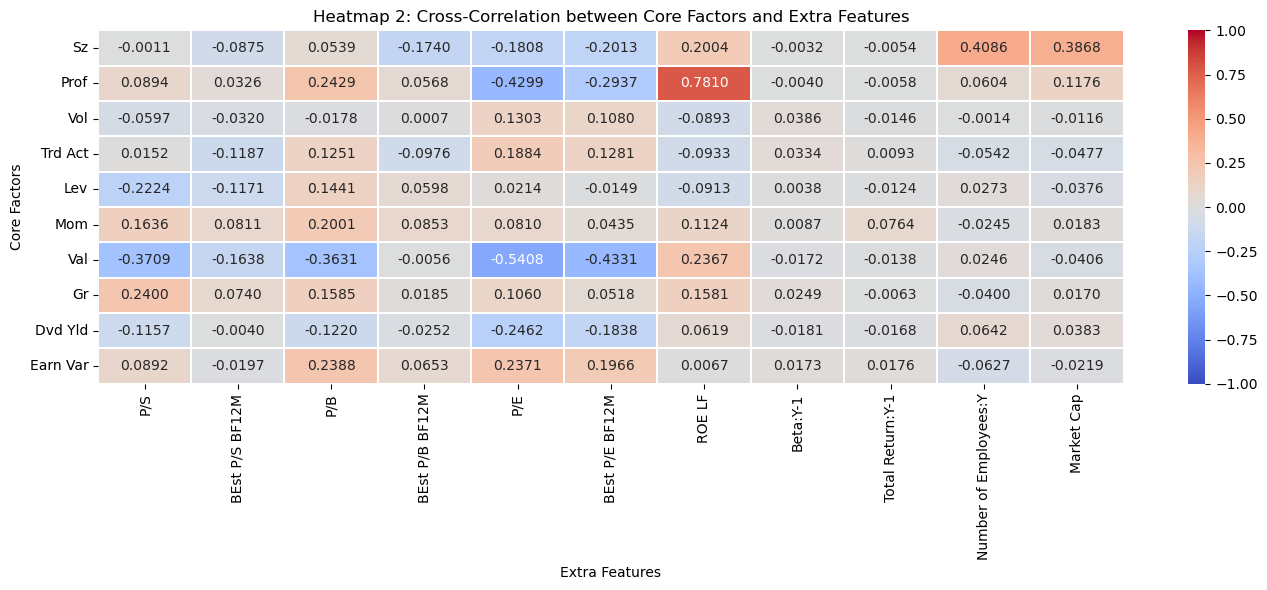

In [14]:
from src.utils.visualizations import plot_cross_correlation_heatmap

# Define your lists (ensure these are defined in your notebook)
rsk_cols = ['Sz', 'Prof', 'Vol', 'Trd Act', 'Lev', 'Mom', 'Val', 'Gr', 'Dvd Yld', 'Earn Var']
extranames = [
    'P/S', 'BEst P/S BF12M', 'P/B', 'BEst P/B BF12M',
    'P/E', 'BEst P/E BF12M', 'ROE LF', 'Beta:Y-1',
    'Total Return:Y-1', 'Number of Employees:Y', 'Market Cap'
]

# Plot Heatmap 2: Cross-Correlation
plot_cross_correlation_heatmap(
    df, 
    row_cols=rsk_cols, 
    col_cols=extranames, 
    title="Heatmap 2: Cross-Correlation between Core Factors and Extra Features"
)

In [15]:
cross_corr_matrix = full_corr.loc[rsk_cols, extranames]

# Max |correlation| of each extra feature vs any core factor
extra_vs_core_abs = cross_corr_matrix.abs()

max_corr_with_core = extra_vs_core_abs.max(axis=0).sort_values(ascending=False)
max_corr_with_core

ROE LF                   0.781047
P/E                      0.540832
BEst P/E BF12M           0.433125
Number of Employees:Y    0.408619
Market Cap               0.386767
P/S                      0.370926
P/B                      0.363073
BEst P/B BF12M           0.173996
BEst P/S BF12M           0.163800
Total Return:Y-1         0.076431
Beta:Y-1                 0.038581
dtype: float64

In [16]:
from src.factors.factor_analysis import get_feature_decisions

# Run the decision logic
decision_df = get_feature_decisions(df, rsk_cols, extranames)

# Display the result
display(decision_df)

2026-03-06 14:27:24,757 - INFO - Calculating feature redundancy decisions...


,feature,max_abs_corr_with_core,rule_based_decision
0,ROE LF,0.781047,drop: very high redundancy (|r| > 0.7)
1,P/E,0.540832,drop: high redundancy (|r| > 0.5)
2,BEst P/E BF12M,0.433125,review: moderate correlation (0.4 < |r| <= 0.5)
3,Number of Employees:Y,0.408619,review: moderate correlation (0.4 < |r| <= 0.5)
4,Market Cap,0.386767,keep candidate: low correlation (|r| <= 0.4)
5,P/S,0.370926,keep candidate: low correlation (|r| <= 0.4)
6,P/B,0.363073,keep candidate: low correlation (|r| <= 0.4)
7,BEst P/B BF12M,0.173996,keep candidate: low correlation (|r| <= 0.4)
8,BEst P/S BF12M,0.163800,keep candidate: low correlation (|r| <= 0.4)
9,Total Return:Y-1,0.076431,keep candidate: low correlation (|r| <= 0.4)


* If feature is a trailing multiple (P/S, P/B, P/E) and there is a forward BEst version with similar loading → prefer forward and drop trailing.
* If feature is a pure size proxy (Market Cap, Number of Employees:Y) and Sz already captures size → drop, even if correlation < 0.4.

In [17]:
pairs_to_inspect = [
    ('Prof', 'ROE LF'),
    ('Val', 'P/E'),
    ('Val', 'BEst P/E BF12M'),
    ('Sz', 'Market Cap'),
    ('Sz', 'Number of Employees:Y'),
    ('Mom', 'Total Return:Y-1'),
    ('Beta:Y-1', 'Total Return:Y-1'),
]

for core, extra in pairs_to_inspect:
    r = full_corr.loc[core, extra]
    print(f"{core:15s} vs {extra:25s}: {r: .3f}")

Prof            vs ROE LF                   :  0.781
Val             vs P/E                      : -0.541
Val             vs BEst P/E BF12M           : -0.433
Sz              vs Market Cap               :  0.387
Sz              vs Number of Employees:Y    :  0.409
Mom             vs Total Return:Y-1         :  0.076
Beta:Y-1        vs Total Return:Y-1         : -0.960


DROP both `Market Cap` and `Number of Employees:Y ` as our Sz factor already captures size.

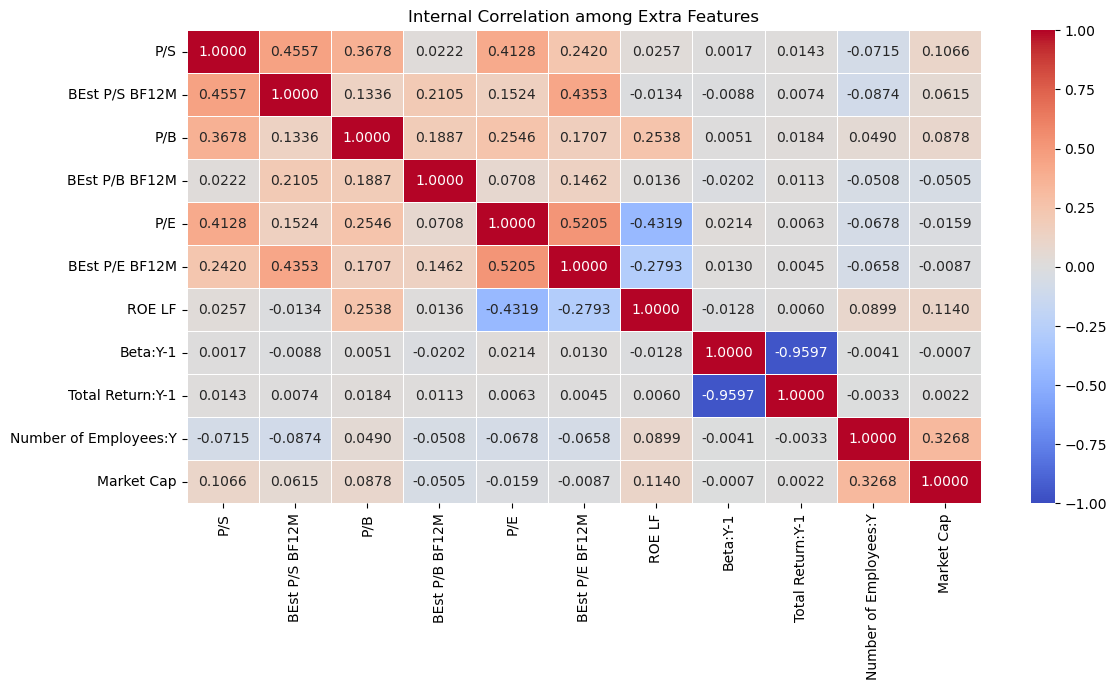

In [18]:
from src.utils.visualizations import plot_correlation_heatmap

# Plot Internal Correlation among Extra Features
plot_correlation_heatmap(
    df, 
    cols=extranames, 
    title="Internal Correlation among Extra Features", 
    figsize=(12, 7)
)

In [19]:
# Final manual decisions

keep_extra = [
    'BEst P/S BF12M',   # low correlation with core factors, forward multiple
    'BEst P/B BF12M',   # low correlation, forward multiple
    'BEst P/E BF12M',   # moderate correlation, but forward-looking
    'Beta:Y-1',         # essentially uncorrelated with core factors
    'Total Return:Y-1'  # provisionally keep for investigation in 1.3
]

drop_extra = [
    'ROE LF',                   # very high corr with Prof
    'P/S', 'P/B', 'P/E',        # trailing versions of multiples
    'Market Cap',
    'Number of Employees:Y'     # conceptual size proxies, redundant with Sz
]

print("KEEP (provisional):", keep_extra)
print("DROP:", drop_extra)

KEEP (provisional): ['BEst P/S BF12M', 'BEst P/B BF12M', 'BEst P/E BF12M', 'Beta:Y-1', 'Total Return:Y-1']
DROP: ['ROE LF', 'P/S', 'P/B', 'P/E', 'Market Cap', 'Number of Employees:Y']


**SELECTION PROCESS RESULTS (SUMMARY)**

* `ROE LF`:
  * Very strong correlation with Prof (~0.78).
  * Adds no new information → drop.

* Trailing multiples (`P/S`, `P/B`, `P/E`):
  * Correlated with Val, but we have forward versions that are more relevant for pricing.
  * Forward metrics (“BEst …”) reflect analyst expectations.

* `Market Cap`, `Number of Employees:Y`:
  * Both are essentially size proxies; Sz already plays that role.

* `Beta:Y-1`:
  * Very low correlation with all core factors → brings in systematic risk dimension not already captured.

* `Total Return:Y-1`:
  * Looks weakly correlated with Mom in Pearson (~0.076), but has weird behaviour:
    * Very strong negative correlation with Beta:Y-1 (~–0.96) → suspicious.
    * Spearman rank correlation with Mom is actually high (~0.79) → “hidden redundancy”.

#### **The `Total Return:Y-1` Investigation: Solving a Statistical Puzzle**

In Section 1.2, our analysis of `Total Return:Y-1` uncovered a major statistical puzzle.

Before diving in, let's clearly define the features at the center of this investigation.

* **`Total Return:Y-1` (Total Return):** This is the simplest concept. It's a stock's individual performance over the last 12 months. Did it go up +50% or down -20%? It is an *absolute* measure of its own movement.
* **`Beta:Y-1` (Beta):** This is **not** a measure of return; it's a measure of *relative volatility* or *systematic risk*. It answers the question: "When the entire market (e.g., the S&P 500) moves up 1%, how much does this stock *tend* to move?" A high-beta stock (e.g., 2.0) is highly volatile and linked to the market. A low-beta stock (e.g., 0.5) is more stable. A stock can have a high `Total Return` but a low `Beta` (it went up a lot, but on its own terms, not with the market). Because they are different concepts, a -0.96 correlation is nonsensical.
* **`Mom` (Momentum Factor):** This is a standardized factor *designed* to capture the momentum effect. Its **primary component is the 12-month return**, often with the most recent month skipped to avoid reversals.

In [20]:
# Keep only the rows where all three variables are available
corr_cols = ['Beta:Y-1', 'Total Return:Y-1', 'Mom']

# Drop rows where any of the three are missing, so we compare like-for-like
df_tr = df[corr_cols].dropna()

print(f"Sample size (non-missing Beta, Total Return, Mom): {len(df_tr):,} rows")

Sample size (non-missing Beta, Total Return, Mom): 167,776 rows


In [21]:
# Raw Pearson correlations (the "mystery" correlations)

beta_tr_pearson = df_tr['Beta:Y-1'].corr(df_tr['Total Return:Y-1'])
mom_tr_pearson = df_tr['Mom'].corr(df_tr['Total Return:Y-1'])

print("RAW PEARSON CORRELATIONS (mystery setup)")
print("-" * 59)
print(f"Corr[Beta:Y-1, Total Return:Y-1] = {beta_tr_pearson: .6f}")
print(f"Corr[Mom,       Total Return:Y-1] = {mom_tr_pearson: .6f}")

RAW PEARSON CORRELATIONS (mystery setup)
-----------------------------------------------------------
Corr[Beta:Y-1, Total Return:Y-1] = -0.959669
Corr[Mom,       Total Return:Y-1] =  0.076431


The data presented two contradictory findings that required investigation:

1.  **A Phantom Correlation:** It showed a **-0.96 Pearson correlation** with `Beta:Y-1`.
2.  **A Hidden Correlation:** It showed a **0.076 Pearson correlation** with our core `Mom` factor.

This is a critical puzzle. The first finding is economically nonsensical, while the second is highly suspicious.

In [22]:
# Spearman rank correlations (robust to outliers)
# Rank each series. We keep the default "average" method; Spearman only cares
# about relative order, not the exact values.
beta_rank = df_tr['Beta:Y-1'].rank(method='average')
tr_rank   = df_tr['Total Return:Y-1'].rank(method='average')
mom_rank  = df_tr['Mom'].rank(method='average')

beta_tr_spearman = beta_rank.corr(tr_rank)
mom_tr_spearman  = mom_rank.corr(tr_rank)

print("SPEARMAN RANK CORRELATIONS (outlier-robust)")
print("-" * 60)
print(f"Spearman[Beta:Y-1, Total Return:Y-1] = {beta_tr_spearman: .6f}")
print(f"Spearman[Mom,       Total Return:Y-1] = {mom_tr_spearman: .6f}")

SPEARMAN RANK CORRELATIONS (outlier-robust)
------------------------------------------------------------
Spearman[Beta:Y-1, Total Return:Y-1] =  0.000252
Spearman[Mom,       Total Return:Y-1] =  0.789623


Interpretation:
- For Beta vs Total Return:
    Spearman ≈ 0.00025  → effectively zero -> "phantom" Pearson correlation
- For Mom vs Total Return:
    Spearman ≈ 0.790    → very high → strong redundancy in the rank ordering

So Beta is statistically unrelated to Total Return, but Mom and Total Return are almost the same variable in rank space.

In [23]:
# To confirm that the -0.96 Pearson correlation is caused by extreme outliers,
# we clip both variables to more economically reasonable ranges.

beta_clip = df_tr['Beta:Y-1'].clip(lower=0.0, upper=2.0)
tr_clip   = df_tr['Total Return:Y-1'].clip(lower=-75, upper=250) * 0.01

# We don't actually need to clip Mom; we just use it as-is
mom_clip = df_tr['Mom']

beta_tr_pearson_clipped = beta_clip.corr(tr_clip)
mom_tr_pearson_clipped  = mom_clip.corr(tr_clip)

print("PEARSON CORRELATION AFTER CLIPPING EXTREME OUTLIERS")
print("-" * 60)
print(f"Corr_clipped[Beta:Y-1, Total Return:Y-1] = {beta_tr_pearson_clipped: .6f}")
print(f"Corr_clipped[Mom,       Total Return:Y-1] = {mom_tr_pearson_clipped: .6f}")

PEARSON CORRELATION AFTER CLIPPING EXTREME OUTLIERS
------------------------------------------------------------
Corr_clipped[Beta:Y-1, Total Return:Y-1] =  0.054961
Corr_clipped[Mom,       Total Return:Y-1] =  0.787301


In [24]:
# Put the key numbers in a summary DataFrame
corr_summary = pd.DataFrame({
    'pair': [
        'Beta:Y-1 vs Total Return:Y-1',
        'Mom vs Total Return:Y-1'
    ],
    'pearson_raw': [
        beta_tr_pearson,
        mom_tr_pearson
    ],
    'spearman_rank': [
        beta_tr_spearman,
        mom_tr_spearman
    ],
    # Pearson using *clipped* Total Return:Y-1 for both pairs
    'pearson_clipped_TR': [
        beta_tr_pearson_clipped,
        mom_tr_pearson_clipped
    ]
})

print("SUMMARY TABLE: PEARSON vs SPEARMAN (with clipped TR)")
print("-" * 60)
display(corr_summary)

SUMMARY TABLE: PEARSON vs SPEARMAN (with clipped TR)
------------------------------------------------------------


,pair,pearson_raw,spearman_rank,pearson_clipped_TR
0,Beta:Y-1 vs Total Return:Y-1,-0.959669,0.000252,0.054961
1,Mom vs Total Return:Y-1,0.076431,0.789623,0.787301


We now act on the statistical conclusion:
 - Beta and Total Return are *not* related once we handle outliers.
 - Mom and Total Return are *highly redundant* in rank space.

 **Therefore, `Total Return:Y-1` is a noisy duplicate of the `Mom` factor,and we drop it from our keep_extra.**

In [25]:
if 'Total Return:Y-1' in keep_extra:
    keep_extra = [col for col in keep_extra if col != 'Total Return:Y-1']

print(f"UPDATED extranames (after dropping Total Return:Y-1): {keep_extra}")

UPDATED extranames (after dropping Total Return:Y-1): ['BEst P/S BF12M', 'BEst P/B BF12M', 'BEst P/E BF12M', 'Beta:Y-1']


In [26]:
# Apply clipping to Beta:Y-1 directly in the main DataFrame
df['Beta:Y-1'] = df['Beta:Y-1'].clip(lower=0.0, upper=2.0)

# Quick sanity check
print(df['Beta:Y-1'].min(), df['Beta:Y-1'].max())

0.0 2.0


Boxplot sample size: 170,886 rows


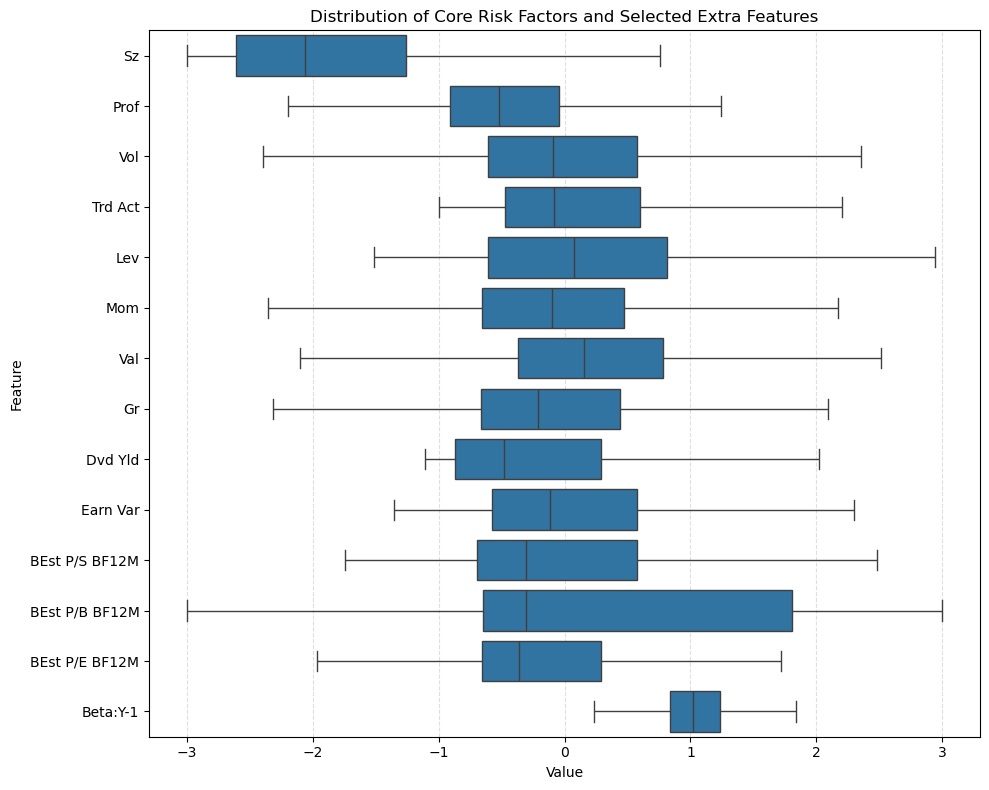

In [27]:
from src.utils.visualizations import plot_box_distribution

box_cols = rsk_cols + keep_extra

# Plot Box Distribution
plot_box_distribution(
    df, 
    cols=box_cols, 
    title="Distribution of Core Risk Factors and Selected Extra Features"
)

#### **Target Variable (FwdRet) Analysis**

First, permanently drop all rows where FwdRet is NaN. We cannot model or analyze data without a target.

`df = df.loc[df['FwdRet'].notna()]`

In [28]:
from scipy import stats

# PERMANENTLY drop rows with missing FwdRet
# This is safe because you literally have no label there.
df = df.loc[df['FwdRet'].notna()].copy()

print("Number of rows after dropping NaN FwdRet:", len(df))
print("Remaining NaNs in FwdRet:", df['FwdRet'].isna().sum())

Number of rows after dropping NaN FwdRet: 166027
Remaining NaNs in FwdRet: 0


In [29]:
# 1. Isolate FwdRet for analysis
fwdret_raw = df['FwdRet'].dropna()

# Basic descriptive statistics
fwdret_desc = fwdret_raw.describe()
fwdret_skew = fwdret_raw.skew()
fwdret_kurt = fwdret_raw.kurtosis()

print("Raw FwdRet summary stats:")
print(fwdret_desc)
print(f"\nSkew: {fwdret_skew:.4f}")
print(f"Kurtosis (Fisher): {fwdret_kurt:.4f}")

Raw FwdRet summary stats:
count    166027.000000
mean          0.038304
std           0.235170
min          -0.983596
25%          -0.077051
50%           0.029558
75%           0.138179
max          13.265487
Name: FwdRet, dtype: float64

Skew: 4.0798
Kurtosis (Fisher): 124.6617


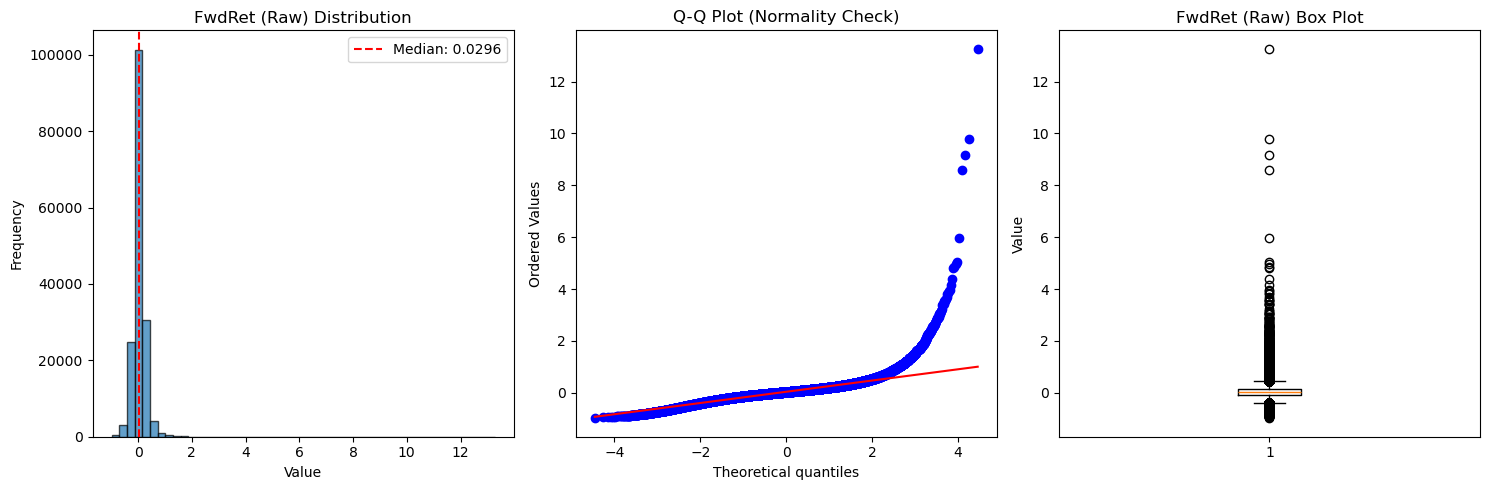

In [30]:
from src.utils.visualizations import plot_distribution_diagnostics

plot_distribution_diagnostics(
    df['FwdRet'], 
    title_prefix="FwdRet (Raw)"
)

Notice that the bulk of the distribution crammed near zero with a long right tail. These graphs confirmed that a few points are off the charts. In the QQ plot, notice that massive deviations in the tails, especially on the right side, confirming that a Gaussian assumption is nonsense without taming the extremes.

#### Global Financial Crisis Sanity Check

In [31]:
dates = df.index.get_level_values(0)

# Define GFC Period (using proper Timestamp objects for safety)
gfc_start = pd.Timestamp('2007-10-01')
gfc_end = pd.Timestamp('2009-01-01')

# Create the Boolean Mask
gfc_period = (dates >= gfc_start) & (dates <= gfc_end)

print("GFC rows:", gfc_period.sum())

GFC rows: 9254


In [32]:
# 2.1 Bertha's trimming: remove everything outside 10–90% quantiles
lower_q = df['FwdRet'].quantile(0.10)
upper_q = df['FwdRet'].quantile(0.90)

trim_mask = (
    gfc_period &
    (df['FwdRet'] >= lower_q) &
    (df['FwdRet'] <= upper_q)
)

trimmed_ret = df.loc[trim_mask, 'FwdRet']
trimmed_lev = df.loc[trim_mask, 'Lev']

trim_corr = trimmed_ret.corr(trimmed_lev)

print(f"Trimmed (10/90) Lev–FwdRet correlation during GFC: {trim_corr:.4f}")
print("Trimmed sample size:", len(trimmed_ret))

Trimmed (10/90) Lev–FwdRet correlation during GFC: 0.0015
Trimmed sample size: 5972


**Interpretation:**

* The correlation is about +0.0015.
* Still financially nonsensical: it says higher leverage helped you in GFC, which completely contradicts 2008 reality.
* Also, trimming literally drops all those crisis-stress points that risk managers care about.

**This is the “Bertha broke the fund” moment: by deleting outliers, she deleted the very scenarios the fund must survive.**

In [33]:
# Clipping bake-off over a grid of quantiles
quantiles_to_test = [0.001, 0.002, 0.004, 0.008, 0.016, 0.032]

clip_results = []

for q in quantiles_to_test:
    lower_clip = df['FwdRet'].quantile(q)
    upper_clip = df['FwdRet'].quantile(1 - q)

    # Clip returns (this is temporary; we don't modify df yet)
    fwdret_clipped_tmp = df['FwdRet'].clip(lower=lower_clip, upper=upper_clip)

    # GFC correlation using clipped returns but same rows
    fwdret_gfc = fwdret_clipped_tmp[gfc_period]
    lev_gfc = df.loc[gfc_period, 'Lev']
    gfc_corr = fwdret_gfc.corr(lev_gfc)

    # Global skew & kurtosis for the clipped series
    skew_tmp = fwdret_clipped_tmp.skew()
    kurt_tmp = fwdret_clipped_tmp.kurtosis()

    # How many points got clipped?
    num_clipped = ((df['FwdRet'] < lower_clip) | (df['FwdRet'] > upper_clip)).sum()

    clip_results.append({
        "q": q,
        "lower_clip": lower_clip,
        "upper_clip": upper_clip,
        "gfc_corr": gfc_corr,
        "skew": skew_tmp,
        "kurtosis": kurt_tmp,
        "num_clipped": num_clipped
    })

clip_df = pd.DataFrame(clip_results).sort_values("q")
clip_df

,q,lower_clip,upper_clip,gfc_corr,skew,kurtosis,num_clipped
0,0.001,-0.757717,1.692811,-0.058917,1.101255,7.145129,334
1,0.002,-0.702111,1.335206,-0.059883,0.865916,4.991422,666
2,0.004,-0.627490,1.035826,-0.059907,0.635341,3.249688,1330
3,0.008,-0.543860,0.795509,-0.058383,0.421113,1.885846,2658
4,0.016,-0.452464,0.605073,-0.054254,0.251458,0.857382,5314
5,0.032,-0.356326,0.460809,-0.048692,0.143393,0.064663,10626


In [34]:
# Choose clipping quantile based on clip_df
best_q = 0.008

lower_clip = df['FwdRet'].quantile(best_q)
upper_clip = df['FwdRet'].quantile(1 - best_q)

print(f"Chosen q = {best_q}")
print(f"Lower clip at {lower_clip:.4f}, upper clip at {upper_clip:.4f}")

Chosen q = 0.008
Lower clip at -0.5439, upper clip at 0.7955


In [35]:
# CRITICAL: Save original, unclipped returns for later P&L work (Section 3.2)
if 'FwdRetOrig' not in df.columns:
    df['FwdRetOrig'] = df['FwdRet'].copy()

# Apply clipping to the live target column
df['FwdRet'] = df['FwdRet'].clip(lower=lower_clip, upper=upper_clip)

# We drop rows where FwdRet is NaN
df['FwdRet'] = df['FwdRet'].dropna()

# Sanity check: how many rows were dropped?
print("Number of rows dropped:", len(df) - len(df['FwdRet']))

# Sanity check: how many observations were clipped?
num_clipped_final = ((df['FwdRetOrig'] < lower_clip) | (df['FwdRetOrig'] > upper_clip)).sum()
print("Number of observations clipped at chosen q:", num_clipped_final)

Number of rows dropped: 0
Number of observations clipped at chosen q: 2658


In [36]:
fwdret_clipped = df['FwdRet']

fwdret_clipped_desc = fwdret_clipped.describe()
fwdret_clipped_skew = fwdret_clipped.skew()
fwdret_clipped_kurt = fwdret_clipped.kurtosis()

print("Clipped FwdRet summary stats:")
print(fwdret_clipped_desc)
print(f"\nSkew (clipped): {fwdret_clipped_skew:.4f}")
print(f"Kurtosis (Fisher, clipped): {fwdret_clipped_kurt:.4f}")

Clipped FwdRet summary stats:
count    166027.000000
mean          0.035501
std           0.206153
min          -0.543860
25%          -0.077051
50%           0.029558
75%           0.138179
max           0.795509
Name: FwdRet, dtype: float64

Skew (clipped): 0.4211
Kurtosis (Fisher, clipped): 1.8858


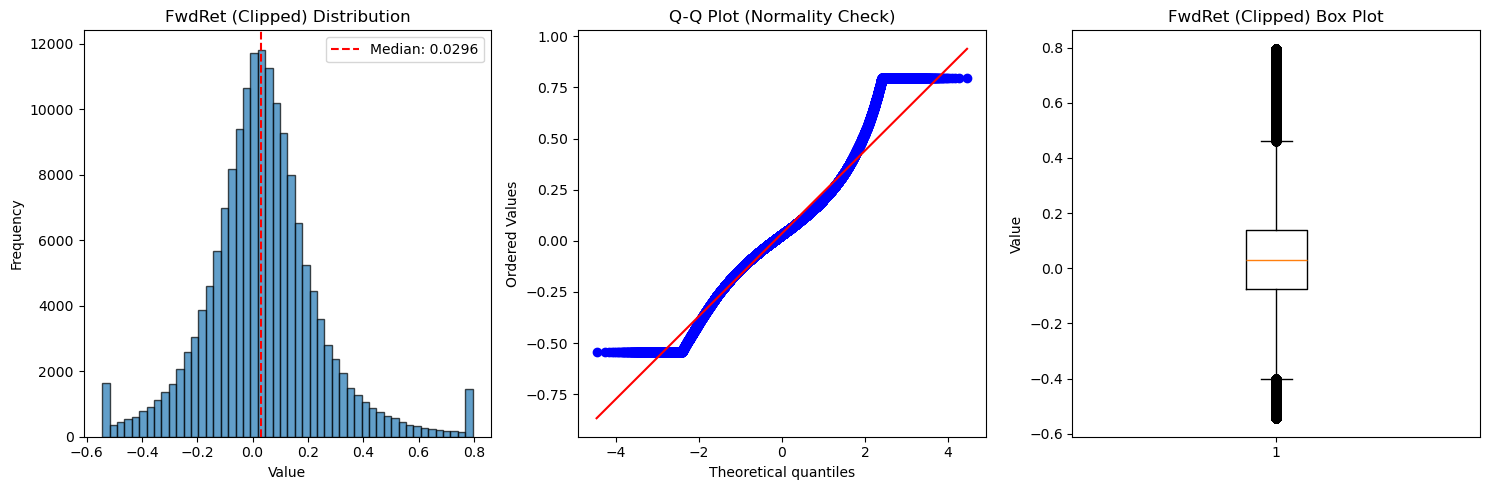

In [37]:
# 2. Analyze Clipped FwdRet (assuming you have performed the clipping)
# Access the clipped column directly
plot_distribution_diagnostics(
    df['FwdRet'], 
    title_prefix="FwdRet (Clipped)"
)

#### **Feature Engineering & Mandate-Driven Selection**

Now that the target variable is clean, we must engineer the features. This is a multi-step process that involves:

1.  **Enforcing Business Rules:** Cleaning data based on the fund's non-negotiable mandates.
2.  **Smart Engineering:** Creating robust categorical features by handling rare cases and missing data with a hierarchical logic.
3.  **Empirical Testing:** Running a "bake-off" to prove which feature set is the most predictive *before* moving on to complex modeling.

In [38]:
# Define needed variable
final_numerical_features = rsk_cols + keep_extra

# Start from the cleaned df (FwdRet NaNs already dropped in 1.4)
print(df.shape)

# Drop high-dimensional columns
high_missing_cols = [
    'ESG Disclosure Score (Latest Available) (BLOOMBERG L.P.)',
    'Number of Employees:Y-5'
]

# Only drop if they exist in the DF
cols_to_drop_high_missing = [c for c in high_missing_cols if c in df.columns]
print("Dropping high-missingness columns:", cols_to_drop_high_missing)

df = df.drop(columns=cols_to_drop_high_missing)
print(df.shape)

# Drop redundant / duplicate columns
redundant_cols = []

# Ticker.1 is explicitly redundant if present
if 'Ticker.1' in df.columns:
    redundant_cols.append('Ticker.1')

# Drop numeric GICS code columns (not the name columns)
for c in df.columns:
    if ('GICS' in c) and (df[c].dtype != 'O'):
        redundant_cols.append(c)

# Remove duplicates in case some columns match multiple rules
redundant_cols = sorted(set(redundant_cols))
print("Dropping redundant GICS / ticker columns:", redundant_cols)

df = df.drop(columns=redundant_cols)
print(df.shape)

# Enforce LRCM size mandate: Sz > -2.2

before_rows = df.shape[0]
df = df.loc[df['Sz'] > -2.2].copy()
after_rows = df.shape[0]

print(f"Applied Sz > -2.2 filter: {before_rows} -> {after_rows} rows")

(166027, 34)
Dropping high-missingness columns: ['ESG Disclosure Score (Latest Available) (BLOOMBERG L.P.)', 'Number of Employees:Y-5']
(166027, 32)
Dropping redundant GICS / ticker columns: ['GICS_Industry', 'GICS_Sector', 'GICS_SubInd', 'Ticker.1']
(166027, 28)
Applied Sz > -2.2 filter: 166027 -> 93829 rows


In [39]:
gics_cols = [
    'GICS_Sector_Name',
    'GICS_Industry_Name',
    'GICS_SubInd_Name'
]

# Handle rare categories across full 25-year dataset
rare_thresh = 500
for col in gics_cols:
    vc = df[col].value_counts(dropna=True)
    rare_categories = vc[vc < rare_thresh].index

    print(f"{col}: {len(rare_categories)} categories flagged as rare (< {rare_thresh})")

    # Set rare categories to NaN
    df.loc[df[col].isin(rare_categories), col] = np.nan
print()
for col in gics_cols:
    print(col, "remaining unique values:", df[col].nunique(dropna=True))

GICS_Sector_Name: 1 categories flagged as rare (< 500)
GICS_Industry_Name: 17 categories flagged as rare (< 500)
GICS_SubInd_Name: 77 categories flagged as rare (< 500)

GICS_Sector_Name remaining unique values: 10
GICS_Industry_Name remaining unique values: 48
GICS_SubInd_Name remaining unique values: 67


- Any category with fewer than 500 observations is deemed too small and is set to NaN.
- This avoids having the model “learn” from tiny groups that are essentially noise (for example, a sub-industry with 37 rows over 25 years).

In [40]:
# Hierarchical fill using GICS tree

# 1) Sector: any NaN Sector becomes 'Other'
df['GICS_Sector_Name'] = df['GICS_Sector_Name'].fillna('Other')

# 2) Industry: missing Industry gets filled from Sector
ind_na = df['GICS_Industry_Name'].isna()
df.loc[ind_na, 'GICS_Industry_Name'] = df.loc[ind_na, 'GICS_Sector_Name']

# 3) SubInd: missing SubInd gets filled from (now cleaned) Industry
sub_na = df['GICS_SubInd_Name'].isna()
df.loc[sub_na, 'GICS_SubInd_Name'] = df.loc[sub_na, 'GICS_Sector_Name']

# Sanity check
for col in gics_cols:
    print(col, "null count after hierarchical fill:", df[col].isna().sum())

GICS_Sector_Name null count after hierarchical fill: 0
GICS_Industry_Name null count after hierarchical fill: 0
GICS_SubInd_Name null count after hierarchical fill: 0


In [41]:
# One-hot encode cleaned and original GICS columns

gics_for_dummies = [
    'GICS_Sector_Name',
    'GICS_Industry_Name',
    'GICS_SubInd_Name'
]

# Keep track of columns before encoding for reference
pre_dummy_cols = set(df.columns)

df = pd.get_dummies(
    df,
    columns=gics_for_dummies,
    prefix=gics_for_dummies,   # use column names as prefixes
    drop_first=False           # keep full set; BayesianRidge can handle multicollinearity
)

post_dummy_cols = set(df.columns)
new_dummy_cols = sorted(post_dummy_cols - pre_dummy_cols)

print(f"Created {len(new_dummy_cols)} GICS dummy columns.")
new_dummy_cols[:10]

Created 145 GICS dummy columns.


['GICS_Industry_Name_Aerospace & Defense',
 'GICS_Industry_Name_Automobile Components',
 'GICS_Industry_Name_Banks',
 'GICS_Industry_Name_Beverages',
 'GICS_Industry_Name_Biotechnology',
 'GICS_Industry_Name_Broadline Retail',
 'GICS_Industry_Name_Building Products',
 'GICS_Industry_Name_Capital Markets',
 'GICS_Industry_Name_Chemicals',
 'GICS_Industry_Name_Commercial Services & Supplies']

In [42]:
import pandas as pd

# 1. Build gdf (Global recent Data Frame)
gdf = df.loc[df.index.get_level_values(0) >= pd.Timestamp('2023-01-01')].copy()

print("gdf shape (Date >= 2023-01):", gdf.shape)

# 2. Verify final numerical features scale
# Ensure 'final_numerical_features' is defined (e.g., rsk_cols + keep_extra)
# If you haven't defined it explicitly yet, you can use:
# final_numerical_features = rsk_cols + keep_extra
if 'final_numerical_features' in locals():
    print("\nFinal numerical feature columns:", final_numerical_features)
    display(gdf[final_numerical_features].describe().T)
else:
    print("⚠️ 'final_numerical_features' list is missing. Please define it first.")

gdf shape (Date >= 2023-01): (8971, 170)

Final numerical feature columns: ['Sz', 'Prof', 'Vol', 'Trd Act', 'Lev', 'Mom', 'Val', 'Gr', 'Dvd Yld', 'Earn Var', 'BEst P/S BF12M', 'BEst P/B BF12M', 'BEst P/E BF12M', 'Beta:Y-1']


,count,mean,std,min,25%,50%,75%,max
Sz,8971.0,-1.198975,0.829507,-2.199910,-1.872959,-1.395740,-0.726697,2.026114
Prof,8971.0,-0.618276,0.878056,-3.000641,-1.102003,-0.700120,-0.154560,3.000621
Vol,8971.0,-0.121275,0.885343,-3.000129,-0.658922,-0.193793,0.307680,3.000134
Trd Act,8971.0,0.348490,0.940584,-0.997746,-0.292864,0.057832,0.679745,3.000360
Lev,8971.0,0.322615,0.918128,-1.422657,-0.351329,0.242618,0.962669,3.000000
Mom,8971.0,-0.236124,0.895558,-3.000075,-0.781640,-0.238005,0.272967,3.000102
Val,8971.0,0.443936,0.899194,-3.000008,-0.186606,0.282642,0.982530,3.000037
Gr,8971.0,-0.294119,0.883250,-3.000069,-0.888518,-0.470945,0.164906,3.000085
Dvd Yld,8971.0,0.192450,0.908442,-0.817272,-0.691396,-0.011735,0.742796,3.000040
Earn Var,8971.0,-0.164902,0.879928,-1.351087,-0.821434,-0.406696,0.264625,3.000237


A few notes here:

- The table here confirmed that:
  - `means` are around 0
  - `stds` are around 1 or less (roughly)
  - `min`/`max` are within a reasonably small range

This backs up the claim that Bloomberg already standardized these factors, so we do not need a StandardScaler later.

In [43]:
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_score, KFold, RandomizedSearchCV

# Candidate GICS classification levels for bake-off
gics_candidates= [
    'GICS_Sector_Name',
    'GICS_Industry_Name',
    'GICS_SubInd_Name'
]

gics_candidates

# Bake-off loop
scoreboard = {}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Target
y_full = gdf['FwdRet'].copy()

for cat_name in gics_candidates:
    # Indicator columns corresponding to this GICS level
    ind_cols = [c for c in gdf.columns if c.startswith(cat_name + '_')]

    if not ind_cols:
        print(f"[Warning] No dummy columns found for {cat_name}. Skipping.")
        continue

    # Build feature matrix: numerical factors + this GICS level's dummies
    X_full = gdf[final_numerical_features + ind_cols].copy()

    # Clean NaNs: keep only rows with complete X and y
    mask = X_full.notna().all(axis=1) & y_full.notna()
    X = X_full.loc[mask]
    y = y_full.loc[mask]

    print(f"\nRunning BayesianRidge for {cat_name}:")
    print(f"  X shape: {X.shape}, y length: {len(y)}")

    # Baseline regularized linear model
    model = BayesianRidge()

    scores = cross_val_score(
        model,
        X,
        y,
        cv=kfold,
        scoring='r2',
        n_jobs=-1
    )

    scoreboard[cat_name] = {
        'mean_r2': scores.mean(),
        'std_r2': scores.std(),
        'scores': scores
    }

    print(f"  CV R^2 scores: {scores}")
    print(f"  Mean R^2: {scores.mean():.4f}  |  Std: {scores.std():.4f}")


Running BayesianRidge for GICS_Sector_Name:
  X shape: (8971, 25), y length: 8971
  CV R^2 scores: [0.02112673 0.04452364 0.02804625 0.01331334 0.03377286]
  Mean R^2: 0.0282  |  Std: 0.0107

Running BayesianRidge for GICS_Industry_Name:
  X shape: (8971, 70), y length: 8971
  CV R^2 scores: [0.02828396 0.04632911 0.02610662 0.01800898 0.03663403]
  Mean R^2: 0.0311  |  Std: 0.0097

Running BayesianRidge for GICS_SubInd_Name:
  X shape: (8971, 92), y length: 8971
  CV R^2 scores: [0.0294647  0.04903466 0.03335715 0.02172193 0.03989776]
  Mean R^2: 0.0347  |  Std: 0.0093


In [44]:
score_rows = []
for cat_name, info in scoreboard.items():
    score_rows.append({
        'GICS_Level': cat_name,
        'Mean_R2': info['mean_r2'],
        'Std_R2': info['std_r2']
    })

score_df = pd.DataFrame(score_rows).sort_values('Mean_R2', ascending=False)
score_df.reset_index(drop=True, inplace=True)

# Identify the best-performing GICS classification

best_row = score_df.iloc[0]
best_cat = best_row['GICS_Level']
best_mean_r2 = best_row['Mean_R2']

print(f"Winner GICS level: {best_cat} with mean R^2 = {best_mean_r2:.4f}")

# Save the chosen indicator columns and final feature set for later parts
winner_ind_cols = [c for c in gdf.columns if c.startswith(best_cat + '_')]

final_feature_columns = final_numerical_features + winner_ind_cols

print(f"Number of numerical features: {len(final_numerical_features)}")
print(f"Number of dummy features from {best_cat}: {len(winner_ind_cols)}")
print(f"Total final feature count: {len(final_feature_columns)}")

Winner GICS level: GICS_SubInd_Name with mean R^2 = 0.0347
Number of numerical features: 14
Number of dummy features from GICS_SubInd_Name: 78
Total final feature count: 92


In [45]:
save_cols = final_feature_columns.copy()

if 'FwdRet' in df.columns:
    save_cols.append('FwdRet')
    print("✅ Added 'FwdRet' to the export list (needed for training).")
else:
    print("⚠️ Warning: 'FwdRet' not found in dataframe. Saving features only.")

# CRITICAL: Preserve unclipped returns for walk-forward P&L (Section 3.2)
if 'FwdRetOrig' in df.columns:
    save_cols.append('FwdRetOrig')
    print("✅ Added 'FwdRetOrig' to the export list (needed for walk-forward P&L).")

# We intersect with df.columns just in case a dummy variable was dropped or missing
valid_cols = [c for c in save_cols if c in df.columns]
df_final = df[valid_cols].copy()

print(f"Final Shape to Save: {df_final.shape}")

# This saves to data/processed/final_model_data.parquet (or similar)
loader.save_processed(df_final, filename="final_model_data.parquet")

print("Success! Data saved to data/processed/final_model_data.parquet")

✅ Added 'FwdRet' to the export list (needed for training).
✅ Added 'FwdRetOrig' to the export list (needed for walk-forward P&L).
Final Shape to Save: (93829, 94)
2026-03-06 14:29:35,027 - INFO - Saved processed data to /Users/aengusmartindonaire/Downloads/Projects/systematic-equity-alpha/data/processed/final_model_data.parquet
Success! Data saved to data/processed/final_model_data.parquet


In [ ]:
# ============================================================== EOF ========================================================================